In [10]:
import pickle 

with open(
    "../../data/processed/CTB/prosit_params/sim_log_s5_sample_30.000_depth10_params.pkl",
    "rb"
) as f:

    params = pickle.load(f)

for act in sorted(
    params.act_to_resources.keys()
):
    print(act)

Gate In
Gate Out
HO2_delivery
HO2_mixed
HO2_receive
LL_delivery
LL_mixed
LL_receive
RMG_delivery
RMG_mixed
RMG_receive


In [12]:
#ACTIVITY RESOURCE MAPPING
for act,res in params.act_to_resources.items():

    print(act, res)

HO2_receive ['HO2']
RMG_receive ['T13', 'T24', 'T14', 'T16', 'T11', 'T20', 'T27', 'T15', 'T21', 'T18', 'T22', 'T23', 'T17', 'T12', 'T06', 'T10', 'T26', 'T09', 'T08', 'T07', 'T19', 'T25']
HO2_delivery ['HO2']
Gate Out ['Res.GateOut']
LL_receive ['LL']
RMG_mixed ['T13', 'T24', 'T14', 'T16', 'T23', 'T20', 'T22', 'T21', 'T27', 'T17', 'T18', 'T10', 'T15', 'T06', 'T09', 'T11', 'T12', 'T07', 'T08', 'T26', 'T19', 'T25']
RMG_delivery ['T14', 'T13', 'T12', 'T17', 'T16', 'T15', 'T21', 'T10', 'T24', 'T11', 'T09', 'T20', 'T19', 'T18', 'T06', 'T27', 'T23', 'T22', 'T07', 'T08', 'T25', 'T26']
HO2_mixed ['HO2']
Gate In ['Res.GateIn']
LL_mixed ['LL']
LL_delivery ['LL']


Inspection of generated Parameters and Models

In [ ]:
params["resource_params"]
params["arrival_params"]
params["calendar_params"]
params["activity_params"]
# ====== Jeweils schauen: 
#Welche Verteilungen wurden gelernt?
#Welche Features tauchen in den Decision Trees auf?
#Sind die neuen Features (target_utilization_bin, target_demand_bin) überhaupt irgendwo im Modell angekommen?
#Werden die Bäume komplexer oder bleiben sie konstant?
#========================================

In [45]:
import pm4py
import pm4py.objects.log.importer.xes.importer as xes_importer
from prosit import SimulatorParameters, SimulatorEngine
log = xes_importer.apply("../../data/processed/CTB/xes_files/s5_sample_30.000_eventlog_one_block_target_features.xes")
net, im, fm = pm4py.discover_petri_net_inductive(log)
params2 = SimulatorParameters(net, im, fm)
params2.from_json("../../data/processed/CTB/prosit_params/sim_log_s5_sample_30.000_depth10_params.json")

c:\Users\Grigat-J\AppData\Local\miniconda3\envs\prosit_test\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
c:\Users\Grigat-J\AppData\Local\miniconda3\envs\prosit_test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 30000/30000 [00:21<00:00, 1374.58it/s]


In [50]:
# Resources discovered from the log
print("discovered resources:", params.resources)

# Working calendar per resource (weekday -> hour -> bool)
print("discovered calender for T24:", params.calendars["T24"])

# Per-resource maximum concurrency (1 = no multitasking, >1 = multitasking)
print("max concurrency:", params.max_concurrency)

# Which resources can perform each activity
#print(params.act_to_resources)

# Whether rules mode (Decision Trees) is active
print("rules mode:", params.rules_mode)

# Arrival time model (DecisionRules in rules mode, distribution tuple in no-rules mode)
print("arrival_time_distribution:", params.arrival_time_distribution)

# Execution time model per activity (DecisionRules or distribution tuple)
print("execution_time_distributions:", params.execution_time_distributions)

# Waiting time model per resource (DecisionRules or distribution tuple)
print("waiting_time_distributions:", params.waiting_time_distributions)

# Resource selection: flat dict {resource: DecisionRules|float}. One binary
# classifier per resource, trained on the events where the resource was
# eligible (activity's candidate pool). At simulation time, the engine first
# filters resources via `act_to_resources[activity]`, scores each enabled
# resource with its own tree, and samples proportionally.
print("resource_weights:", params.resource_weights)

# Control flow model per transition (DecisionRules in rules mode, float frequency in no-rules)
print("transition_weights:", params.transition_weights)

# Case-level data attribute distribution (None if no attributes in log)
print("distribution_data_attributes:", params.distribution_data_attributes)
# {'mode': 'empirical', 'data': {(val1, val2): frequency, ...}}
# or {'mode': 'distribution', 'data': {attr: {'type': 'categorical'|'continuous', ...}}}

discovered resources: ['Res.GateIn', 'Res.GateOut', 'LL', 'T13', 'T14', 'T24', 'T16', 'T17', 'T15', 'T12', 'T21', 'T20', 'T18', 'T11', 'T23', 'T27', 'T22', 'T10', 'T06', 'T09', 'T07', 'T08', 'T26', 'T19', 'T25', 'HO2']
discovered calender for T24: {0: {0: False, 1: False, 2: False, 3: False, 4: False, 5: True, 6: True, 7: True, 8: True, 9: True, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: True, 22: True, 23: True}, 1: {0: True, 1: True, 2: True, 3: True, 4: True, 5: True, 6: True, 7: True, 8: True, 9: True, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: True, 22: True, 23: True}, 2: {0: True, 1: True, 2: True, 3: True, 4: True, 5: True, 6: True, 7: True, 8: True, 9: True, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: True, 22: True, 23: True}, 3: {0: True, 1: True, 2: True, 3: True, 4

Resource Models

In [ ]:
# ================CHECK LEARNED DATA ATTRIBUTES=====================================
# CHECK LEARNED DATA ATTRIBUTES
# =====================================================

import pandas as pd

attrs = (
    params2.distribution_data_attributes
    ["data"]
)

summary = []

for attr, info in attrs.items():

    summary.append({

        "attribute": attr,

        "type": info["type"]

    })

feature_df = pd.DataFrame(summary)

display(
    feature_df.sort_values("attribute")
)

,attribute,type
7,full_ratio,continuous
18,gate_demand,continuous
5,gate_utilization,continuous
3,has_hazardous,continuous
19,has_reefer,continuous
20,mt_demand,continuous
15,mt_utilization,continuous
4,n_containers,continuous
12,n_deliveries,continuous
9,n_receives,continuous


In [ ]:
# ===== FEATURE DISTRIBUTIONS================================================
# FEATURE DISTRIBUTIONS
# =====================================================

from pprint import pprint

for attr, info in (
    params2.distribution_data_attributes["data"]
    .items()
):

    print("\n" + "="*70)
    print(attr)
    print("="*70)

    pprint(info)


target_utilization_bin
{'type': 'categorical',
 'values': {'high': 0.2677083333333333,
            'low': 0.24291666666666667,
            'medium': 0.27466666666666667,
            'very_high': 0.21470833333333333}}

target_demand_bin
{'type': 'categorical',
 'values': {'high': 0.24704166666666666,
            'low': 0.2547916666666667,
            'medium': 0.2542083333333333,
            'very_high': 0.24395833333333333}}

vc_demand
{'dist': 'lognorm',
 'max': 58.38,
 'mean': 19.48424875,
 'min': 0.0,
 'params': [0.2620406349457838, -23.696812611589987, 41.737305839850066],
 'type': 'continuous'}

has_hazardous
{'dist': 'expon',
 'max': 1.0,
 'mean': 0.032375,
 'min': 0.0,
 'params': [0.0, 0.032375],
 'type': 'continuous'}

n_containers
{'dist': 'gamma',
 'max': 4.0,
 'mean': 1.1805,
 'min': 1.0,
 'params': [0.16750424990641977, 0.9999999999999999, 0.3439595461756423],
 'type': 'continuous'}

gate_utilization
{'dist': 'norm',
 'max': 0.65,
 'mean': 0.5874363791666667,
 'min': 0.493

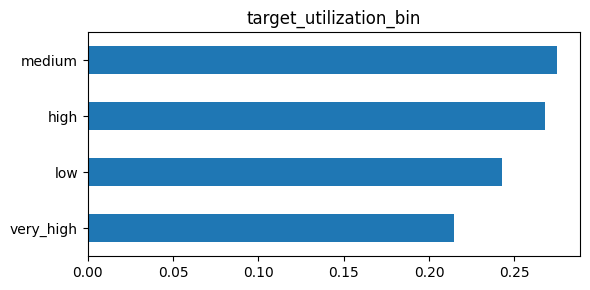

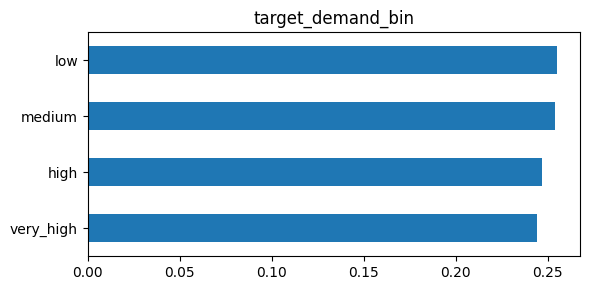

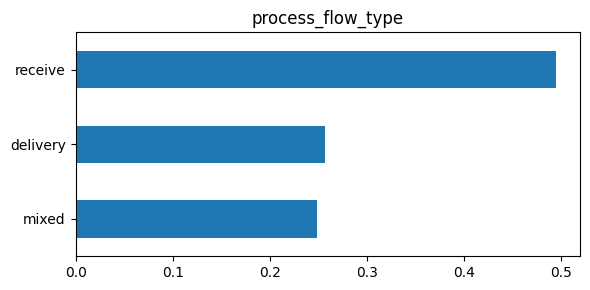

In [ ]:
# ==============CATEGORICAL FEATURES=======================================
# CATEGORICAL FEATURES
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

attrs = (
    params2.distribution_data_attributes["data"]
)

for attr, info in attrs.items():

    if info["type"] != "categorical":
        continue

    values = pd.Series(
        info["values"]
    )

    plt.figure(
        figsize=(6,3)
    )

    values.sort_values().plot.barh()

    plt.title(attr)

    plt.tight_layout()

    plt.show()

In [ ]:
# ================NUMERICAL FEATURE PARAMS=====================================
# NUMERICAL FEATURE PARAMS
# =====================================================

rows = []

for attr, info in (
    params2.distribution_data_attributes["data"]
    .items()
):

    if info["type"] != "continuous":
        continue

    rows.append({

        "attribute": attr,

        "distribution":
            info.get("dist"),

        "mean":
            round(info.get("mean", 0), 3),

        "min":
            round(info.get("min", 0), 3),

        "max":
            round(info.get("max", 0), 3)

    })

num_df = pd.DataFrame(rows)

display(
    num_df.sort_values("attribute")
)

,attribute,distribution,mean,min,max
5,full_ratio,norm,0.821,0.000,1.000
15,gate_demand,norm,126.977,0.670,264.000
3,gate_utilization,norm,0.587,0.494,0.650
1,has_hazardous,expon,0.032,0.000,1.000
16,has_reefer,lognorm,0.064,0.000,1.000
17,mt_demand,norm,18.510,0.000,52.850
12,mt_utilization,norm,0.828,0.690,0.930
2,n_containers,gamma,1.181,1.000,4.000
9,n_deliveries,norm,0.551,0.000,4.000
7,n_receives,norm,0.780,0.000,4.000


In [ ]:
# ====================RESOURCE MODEL TYPES=================================
# RESOURCE MODEL TYPES
# =====================================================

import pandas as pd

rows = []

for res, model in (
    params2.resource_weights.items()
):

    rows.append({

        "resource": res,

        "model_type":
            type(model).__name__

    })

resource_df = pd.DataFrame(rows)

display(
    resource_df
    .sort_values("resource")
)

,resource,model_type
25,HO2,float
2,LL,float
0,Res.GateIn,float
1,Res.GateOut,float
18,T06,DecisionRules
20,T07,DecisionRules
21,T08,DecisionRules
19,T09,DecisionRules
17,T10,DecisionRules
13,T11,float


In [58]:
# ====================FIND FEATURES IN LEARNED TREES=================================
# FIND FEATURES IN LEARNED TREES
# =====================================================

from collections import Counter

counter = Counter()

for obj in params2.resource_weights.values():

    if not hasattr(obj, "__dict__"):
        continue

    text = str(obj.__dict__)

    for feature in [

        "process_flow_type",
            "n_containers",
            "n_stops",
            "n_deliveries",
            "n_receives",
            "has_hazardous",
            "has_reefer",
            "full_ratio",
            "visit_complexity",
            "gate_demand",
            "rmg_demand",
            "vc_demand",
            "mt_demand",
            "gate_utilization",
            "rmg_utilization",
            "vc_utilization",
            "mt_utilization",
            "target_block",
            "target_utilization",
            "target_demand",
            "target_utilization_bin",
            "target_demand_bin",

    ]:

        counter[feature] += text.count(feature)

pd.DataFrame({

    "feature": list(counter.keys()),
    "occurrences": list(counter.values())

}).sort_values(
    "occurrences",
    ascending=False
)

,feature,occurrences
18,target_utilization,10
20,target_utilization_bin,1
6,has_reefer,1
15,vc_utilization,1
14,rmg_utilization,1
0,process_flow_type,0
12,mt_demand,0
19,target_demand,0
17,target_block,0
16,mt_utilization,0


In [59]:
for feature in [

    "target_block",
    "target_utilization",
    "target_demand",

    "target_utilization_bin",
    "target_demand_bin"

]:

    print(
        feature,
        str(params2.__dict__).count(feature)
    )

target_block 0
target_utilization 6
target_demand 6
target_utilization_bin 4
target_demand_bin 4


EXECUTION TIME MODELS

In [60]:
# =====================================================
# EXECUTION MODELS OVERVIEW
# =====================================================

import pandas as pd

rows = []

for act, model in (
    params2.execution_time_distributions.items()
):

    rows.append({

        "activity": act,

        "model_type": type(model).__name__

    })

exec_df = pd.DataFrame(rows)

display(
    exec_df.sort_values("activity")
)

,activity,model_type
7,Gate In,DecisionRules
5,Gate Out,DecisionRules
2,HO2_delivery,DecisionRules
3,HO2_mixed,DecisionRules
1,HO2_receive,DecisionRules
6,LL_delivery,DecisionRules
4,LL_mixed,DecisionRules
0,LL_receive,DecisionRules
9,RMG_delivery,DecisionRules
8,RMG_mixed,DecisionRules


In [61]:
# =====================================================
# FEATURE USAGE IN EXECUTION MODELS
# =====================================================

from collections import Counter

counter = Counter()

features = [

    "target_block",
    "target_utilization",
    "target_demand",

    "target_utilization_bin",
    "target_demand_bin",

    "process_flow_type",

    "n_containers",
    "n_stops",

    "n_deliveries",
    "n_receives",

    "full_ratio",

    "visit_complexity",

    "gate_demand",
    "rmg_demand",
    "vc_demand",
    "mt_demand",

    "gate_utilization",
    "rmg_utilization",
    "vc_utilization",
    "mt_utilization"
]

for act, model in (
    params2.execution_time_distributions.items()
):

    text = str(model.__dict__)

    for feat in features:

        counter[feat] += text.count(feat)

feature_df = pd.DataFrame({

    "feature": list(counter.keys()),
    "occurrences": list(counter.values())

})

feature_df = (
    feature_df
    .sort_values(
        "occurrences",
        ascending=False
    )
)

display(feature_df)


,feature,occurrences
0,target_block,0
1,target_utilization,0
18,vc_utilization,0
17,rmg_utilization,0
16,gate_utilization,0
15,mt_demand,0
14,vc_demand,0
13,rmg_demand,0
12,gate_demand,0
11,visit_complexity,0


In [69]:
for act, model in params2.execution_time_distributions.items():

    print("\n", act)

    for node, info in model.rules.items():

        print(
            "mean:",
            info.get("value")
        )


 LL_receive
mean: 10.4

 HO2_receive
mean: 15.84

 HO2_delivery
mean: 10.018292682926829

 HO2_mixed
mean: 14.25

 LL_mixed
mean: 8.733201581027668

 Gate Out
mean: 0.0

 LL_delivery
mean: 9.629955947136564

 Gate In
mean: 0.0

 RMG_mixed
mean: 13.825095915143308

 RMG_delivery
mean: 8.146794871794873

 RMG_receive
mean: 11.663440618200916


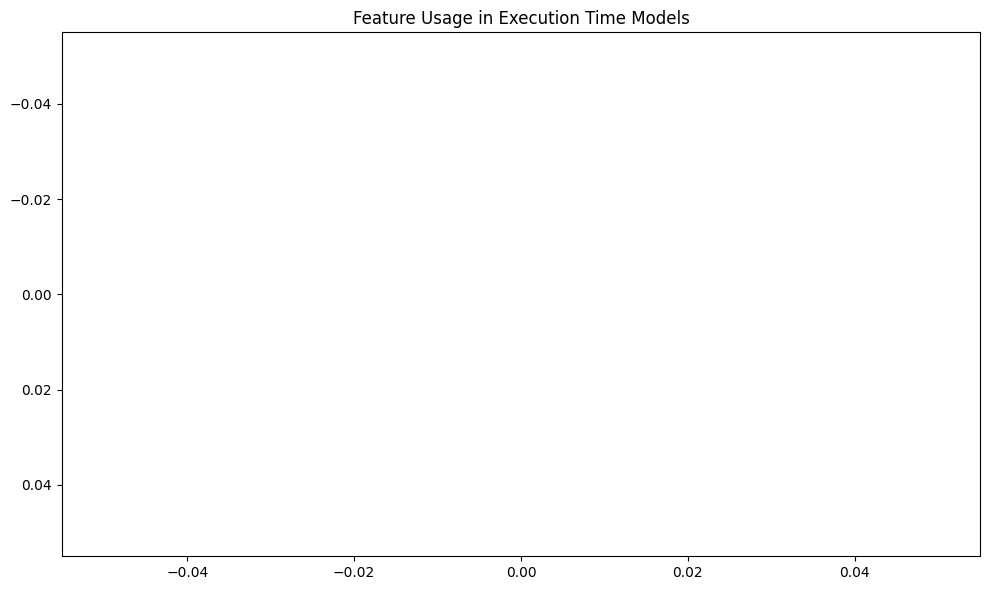

In [62]:
# =====================================================
# FEATURE USAGE BARPLOT
# =====================================================

import matplotlib.pyplot as plt

plot_df = (
    feature_df
    .query("occurrences > 0")
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    plot_df["feature"],
    plot_df["occurrences"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Usage in Execution Time Models"
)

plt.tight_layout()
plt.show()

In [64]:
params2.execution_time_distributions["RMG_delivery"]
# =====================================================
# INSPECT ONE EXECUTION MODEL
# =====================================================

model = (
    params2.execution_time_distributions[
        "RMG_delivery"
    ]
)

print(type(model))

print(model.__dict__.keys())

<class 'prosit.utils.rule_utils.DecisionRules'>
dict_keys(['rules', 'graph'])


In [65]:
from pprint import pprint

model = (
    params2.execution_time_distributions[
        "RMG_delivery"
    ]
)

pprint(model.__dict__)

{'graph': None,
 'rules': {0: {'dist': (<scipy.stats._continuous_distns.gamma_gen object at 0x000001B66EACA680>,
                        (1.8287962417165473,
                         -0.0028052588004881225,
                         4.456280147538048),
                        0.0,
                        145.0),
               'value': 8.146794871794873}}}


In [66]:
# =====================================================
# MODEL SIZE COMPARISON
# =====================================================

rows = []

for act, model in (
    params2.execution_time_distributions.items()
):

    size = len(str(model.__dict__))

    rows.append({

        "activity": act,

        "size": size

    })

size_df = pd.DataFrame(rows)

size_df = (
    size_df
    .sort_values(
        "size",
        ascending=False
    )
)

display(size_df)

,activity,size
8,RMG_mixed,220
10,RMG_receive,220
9,RMG_delivery,219
6,LL_delivery,216
4,LL_mixed,214
3,HO2_mixed,205
0,LL_receive,202
1,HO2_receive,202
2,HO2_delivery,180
5,Gate Out,82


WAITING TIME MODELS

In [70]:
# =====================================================
# WAITING MODEL OVERVIEW
# =====================================================

import pandas as pd

rows = []

for res, model in (
    params2.waiting_time_distributions.items()
):

    rows.append({

        "resource": res,

        "model_type": type(model).__name__

    })

waiting_df = pd.DataFrame(rows)

display(
    waiting_df.sort_values("resource")
)

,resource,model_type
24,HO2,DecisionRules
5,LL,DecisionRules
0,Res.GateIn,DecisionRules
25,Res.GateOut,DecisionRules
16,T06,DecisionRules
20,T07,DecisionRules
19,T08,DecisionRules
21,T09,DecisionRules
17,T10,DecisionRules
15,T11,DecisionRules


In [71]:
# =====================================================
# FEATURE USAGE IN WAITING MODELS
# =====================================================

from collections import Counter

counter = Counter()

features = [

    "target_block",

    "target_utilization",
    "target_demand",

    "target_utilization_bin",
    "target_demand_bin",

    "process_flow_type",

    "n_containers",
    "n_stops",

    "n_deliveries",
    "n_receives",

    "full_ratio",

    "visit_complexity",

    "gate_demand",
    "rmg_demand",
    "vc_demand",
    "mt_demand",

    "gate_utilization",
    "rmg_utilization",
    "vc_utilization",
    "mt_utilization"
]

for res, model in (
    params2.waiting_time_distributions.items()
):

    text = str(model.__dict__)

    for feat in features:

        counter[feat] += text.count(feat)

feature_df = pd.DataFrame({

    "feature": list(counter.keys()),
    "occurrences": list(counter.values())

})

display(
    feature_df.sort_values(
        "occurrences",
        ascending=False
    )
)


,feature,occurrences
0,target_block,0
1,target_utilization,0
18,vc_utilization,0
17,rmg_utilization,0
16,gate_utilization,0
15,mt_demand,0
14,vc_demand,0
13,rmg_demand,0
12,gate_demand,0
11,visit_complexity,0


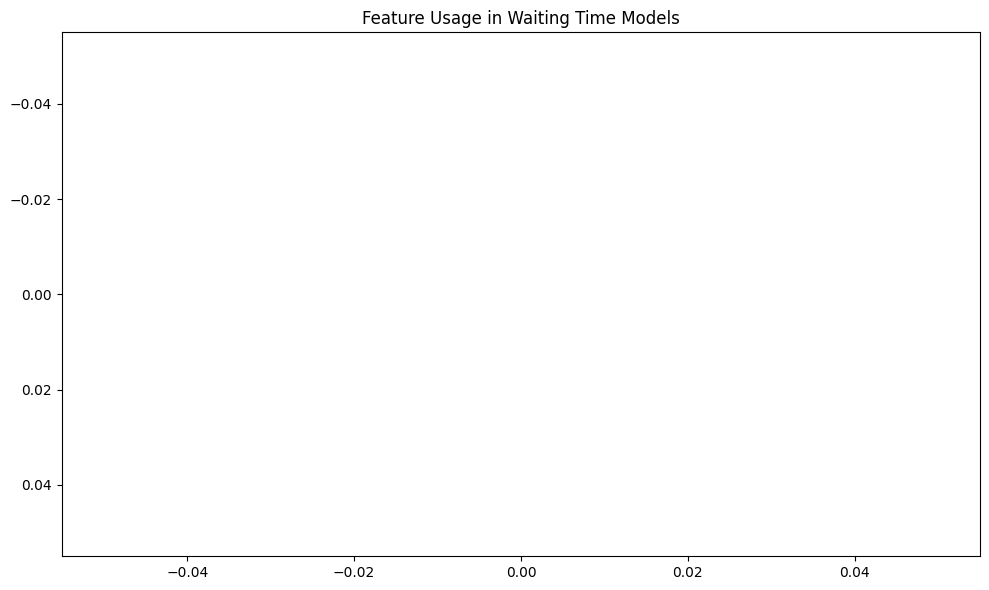

In [72]:
# =====================================================
# WAITING MODEL FEATURE USAGE
# =====================================================

import matplotlib.pyplot as plt

plot_df = (
    feature_df
    .query("occurrences > 0")
)

plt.figure(figsize=(10,6))

plt.barh(
    plot_df["feature"],
    plot_df["occurrences"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Usage in Waiting Time Models"
)

plt.tight_layout()

plt.show()

In [ ]:
# =====================================================
# WAITING MODEL COMPLEXITY - WHIOCH RESOURCES HAVE ACTUAL RULES?
# =====================================================

rows = []

for res, model in (
    params2.waiting_time_distributions.items()
):

    rules = getattr(model, "rules", {})

    rows.append({

        "resource": res,

        "n_rules": len(rules)

    })

waiting_rules_df = pd.DataFrame(rows)

display(
    waiting_rules_df
    .sort_values(
        "n_rules",
        ascending=False
    )
)

,resource,n_rules
17,T10,3
0,Res.GateIn,1
1,T24,1
24,HO2,1
23,T19,1
22,T25,1
21,T09,1
20,T07,1
19,T08,1
18,T26,1


In [77]:
model = (
    params2.waiting_time_distributions["T10"]
)

print(type(model))

print(model.__dict__.keys())
from pprint import pprint

model = (
    params2.waiting_time_distributions["T10"]
)

pprint(model.__dict__)


<class 'prosit.utils.rule_utils.DecisionRules'>
dict_keys(['rules', 'graph'])
{'graph': None,
 'rules': {0: {'children': {False: 2, True: 1},
               'feature': 'queue_length',
               'threshold': 2.5},
           1: {'dist': (<scipy.stats._continuous_distns.expon_gen object at 0x000001B66EA98970>,
                        (0.0, 6.48559670781893),
                        0.0,
                        73.0),
               'value': 6.486},
           2: {'dist': (<scipy.stats._continuous_distns.expon_gen object at 0x000001B66EA98970>,
                        (0.0, 29.75),
                        0.0,
                        127.0),
               'value': 29.75}}}


In [76]:
# =====================================================
# MODEL SIZE COMPARISON
# =====================================================

rows = []

for res, model in (
    params2.waiting_time_distributions.items()
):

    rows.append({

        "resource": res,

        "size": len(str(model.__dict__))

    })

size_df = pd.DataFrame(rows)

display(
    size_df
    .sort_values(
        "size",
        ascending=False
    )
)

,resource,size
17,T10,379
25,Res.GateOut,219
24,HO2,219
4,T13,182
19,T08,182
5,LL,181
8,T12,181
9,T21,181
16,T06,181
1,T24,180


In [78]:
for res, model in (
    params2.waiting_time_distributions.items()
):

    print("\n", res)

    for node, info in model.rules.items():

        print(
            "mean:",
            info.get("value")
        )


 Res.GateIn
mean: 0.0

 T24
mean: 7.742163009404389

 T16
mean: 8.902920284135753

 T14
mean: 7.283527696793003

 T13
mean: 11.193803559657217

 LL
mean: 5.4870283018867925

 T15
mean: 8.284280936454849

 T17
mean: 9.979423868312757

 T12
mean: 6.3236797274275975

 T21
mean: 6.6785095320623915

 T20
mean: 7.26334208223972

 T18
mean: 8.871912168344007

 T23
mean: 6.957798165137615

 T27
mean: 9.561983471074381

 T22
mean: 6.642988929889299

 T11
mean: 11.48487626031164

 T06
mean: 11.434402332361516

 T10
mean: None
mean: 6.486
mean: 29.75

 T26
mean: 9.973714285714285

 T08
mean: 11.442857142857143

 T07
mean: 8.99124726477024

 T09
mean: 9.339375629405842

 T25
mean: 9.643312101910828

 T19
mean: 9.451573849878935

 HO2
mean: 18.9251968503937

 Res.GateOut
mean: 12.932666666666666


In [79]:
for res, model in (
    params2.waiting_time_distributions.items()
):

    print()
    print(res)

    print(
        "graph:",
        model.graph is not None
    )


Res.GateIn
graph: False

T24
graph: False

T16
graph: False

T14
graph: False

T13
graph: False

LL
graph: False

T15
graph: False

T17
graph: False

T12
graph: False

T21
graph: False

T20
graph: False

T18
graph: False

T23
graph: False

T27
graph: False

T22
graph: False

T11
graph: False

T06
graph: False

T10
graph: False

T26
graph: False

T08
graph: False

T07
graph: False

T09
graph: False

T25
graph: False

T19
graph: False

HO2
graph: False

Res.GateOut
graph: False


In [80]:
for res, model in params2.waiting_time_distributions.items():

    if len(model.rules) > 1:

        print()
        print("=" * 50)
        print(res)
        print("=" * 50)

        from pprint import pprint
        pprint(model.rules)


T10
{0: {'children': {False: 2, True: 1},
     'feature': 'queue_length',
     'threshold': 2.5},
 1: {'dist': (<scipy.stats._continuous_distns.expon_gen object at 0x000001B66EA98970>,
              (0.0, 6.48559670781893),
              0.0,
              73.0),
     'value': 6.486},
 2: {'dist': (<scipy.stats._continuous_distns.expon_gen object at 0x000001B66EA98970>,
              (0.0, 29.75),
              0.0,
              127.0),
     'value': 29.75}}


Either Generate a new Sim Log based on saved params or load an existing one below

In [ ]:
# VALIDAT EBASELINE SIMULATION
from prosit.simulator import SimulatorEngine



engine = SimulatorEngine(params)

In [15]:
sim_log = engine.apply(
    n_traces=20000
)

Simulating Cases: 100%|██████████| 20000/20000 [00:45<00:00, 441.27it/s]


In [21]:
#INSEPCT RESULTS:
sim_log["concept:name"]\
    .value_counts()

Gate In         20000
Gate Out        20000
RMG_receive      9231
RMG_delivery     5804
RMG_mixed        4210
HO2_delivery      616
HO2_receive        26
HO2_mixed          20
LL_mixed           15
LL_delivery         2
Name: concept:name, dtype: int64

In [18]:
#SAVE BASELINE SIMULATION
sim_log.to_csv(
    "../../data/processed/CTB/prosit_simulations/sim_log_s5_sample_30.000_depth10.csv",
    index=False
)

KPI CALCULATION

In [30]:
# Load Sim Log
import pandas as pd
sim_log = pd.read_csv("../../data/processed/CTB/prosit_simulations/sim_log_s5_sample_30.000_depth10.csv"
)

In [ ]:
timestamp_cols = [
    "enabled:timestamp",
    "start:timestamp",
    "time:timestamp"
]

for col in timestamp_cols:

    if col in sim_log.columns:

        sim_log[col] = pd.to_datetime(
            sim_log[col],
            utc=True,
            errors="coerce"
        )

In [23]:
waiting = (

    sim_log["start:timestamp"]

    -

    sim_log["enabled:timestamp"]

).dt.total_seconds() / 60

In [24]:
service = (

  sim_log["time:timestamp"]

    - sim_log["start:timestamp"]

).dt.total_seconds() / 60

In [25]:
turnaround = (

   sim_log

    .groupby(
        "case:concept:name"
   )

    .agg(

        start=(
           "start:timestamp",
           "min"
        ),

        end=("time:timestamp",
           "max"
        )

    )

)


In [31]:
#STOREEEEEEEE
baseline_kpis = {

    "scenario": "Baseline",

    "cases": sim_log["case:concept:name"].nunique(),

    "waiting_mean": waiting.mean(),

    "service_mean": service.mean(),

    "turnaround_mean": turnaround.mean(),

    "waiting_median": waiting.median(),

    "service_median": service.median(),

    "turnaround_median": turnaround.median()

}

C:\Users\Grigat-J\AppData\Local\Temp\ipykernel_12740\3255967349.py:12: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  "turnaround_mean": turnaround.mean(),
C:\Users\Grigat-J\AppData\Local\Temp\ipykernel_12740\3255967349.py:18: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  "turnaround_median": turnaround.median()


In [34]:
for k, v in baseline_kpis.items():

    if isinstance(v, (int, float)):
        print(f"{k:20}: {v:.2f}")
    else:
        print(f"{k:20}: {v}")

scenario            : Baseline
cases               : 20000.00
waiting_mean        : 14.64
service_mean        : 4.99
turnaround_mean     : Series([], dtype: float64)
waiting_median      : 4.00
service_median      : 0.00
turnaround_median   : Series([], dtype: float64)


In [32]:
import pandas as pd

pd.DataFrame(
    [baseline_kpis]
).to_csv(

    "baseline_kpis.csv",

    index=False

)

In [36]:
print(len(waiting))
print(len(service))
print(len(turnaround))
print(waiting.head())
print(service.head())
print(turnaround.head())


59924
59924
20000
0    0.0
1    0.0
2    2.0
3    2.0
4    0.0
dtype: float64
0     0.0
1     0.0
2     6.0
3    13.0
4     0.0
dtype: float64
                                             start  \
case:concept:name                                    
case_1            2026-07-28 11:38:00.225704+00:00   
case_10           2026-07-28 11:45:24.225704+00:00   
case_100          2026-07-28 14:16:48.225704+00:00   
case_1000         2026-07-29 17:51:13.225704+00:00   
case_10000               2026-08-13 15:56:09+00:00   

                                               end  
case:concept:name                                   
case_1            2026-07-28 12:04:00.225704+00:00  
case_10           2026-07-28 12:23:24.225704+00:00  
case_100          2026-07-28 15:06:48.225704+00:00  
case_1000         2026-07-29 18:30:13.225704+00:00  
case_10000               2026-08-13 16:05:09+00:00  
